## Raw Data EDA

In [ ]:
import pandas as pd
import numpy as np

from CreditCardApproval.data import load_data
from CreditCardApproval.eda import (
    basic_overview,
    missing_value_summary,
    plot_missing_matrix, 
    unique_value_summary,
    split_num_cat_features,
    describe_numerical_features,
    describe_categorical_features,
    plot_histograms,
    plot_pie_charts,
    plot_binary_bar_charts,
    plot_multiclass_bar_charts,
    transform_birth_and_employed,
    plot_birth_and_employed,
    plot_numeric_boxplots,
    plot_correlation_heatmap,
    plot_credit_records_per_id,
    plot_months_balance_distribution,
    plot_status_distribution,
    add_status_severity,
    plot_severity_distribution,
    aggregate_credit_by_id,
    plot_credit_history_length,
    plot_max_severity_distribution,
    plot_ever_severe_pie,
    build_credit_target
)

In [2]:
# load data
application_df, credit_df = load_data()

***

### I. Brief Overview

In [ ]:
# brief look
print("application information dataset:")
application_df.head()

application information dataset:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
# basic overview of application dataset
basic_overview(application_df)


Number of datapoints for application records: 438557

Number of unique clients in dataset: 438510

Shape: (438557, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13 

In [ ]:
# brief look
print("credit performance dataset:")
credit_df.head()

credit performance dataset:


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
# basic overview of credit dataset
basic_overview(credit_df)


Number of datapoints for application records: 1048575

Number of unique clients in dataset: 45985

Shape: (1048575, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB

Information: None


In [ ]:
# see how many records match in two datasets
print("Number of ID match in two datasets:", len(set(credit_df['ID']).intersection(set(application_df['ID']))))

Number of ID match in two datasets: 36457


Review:

According to basic dataset overview: 
* The application dataset contains 438,557 applicants with 18 personal features.
* The credit dataset is a panel dataset with 1,048,575 total but 45,985 unique observations, where each applicant may have multiple monthly credit records.
*  These two datasets have 36,457 interacted clients.

***

### II. Application Information EDA

##### 1. Missing Value Analysis

In [ ]:
# Missing value
print("Missing values of application_df:")
missing_value_summary(application_df)

Missing values of application_df:


,missing_count,missing_rate
OCCUPATION_TYPE,134203,0.30601
ID,0,0.00000
CODE_GENDER,0,0.00000
FLAG_OWN_CAR,0,0.00000
CNT_CHILDREN,0,0.00000
FLAG_OWN_REALTY,0,0.00000
NAME_INCOME_TYPE,0,0.00000
NAME_EDUCATION_TYPE,0,0.00000
NAME_FAMILY_STATUS,0,0.00000
AMT_INCOME_TOTAL,0,0.00000


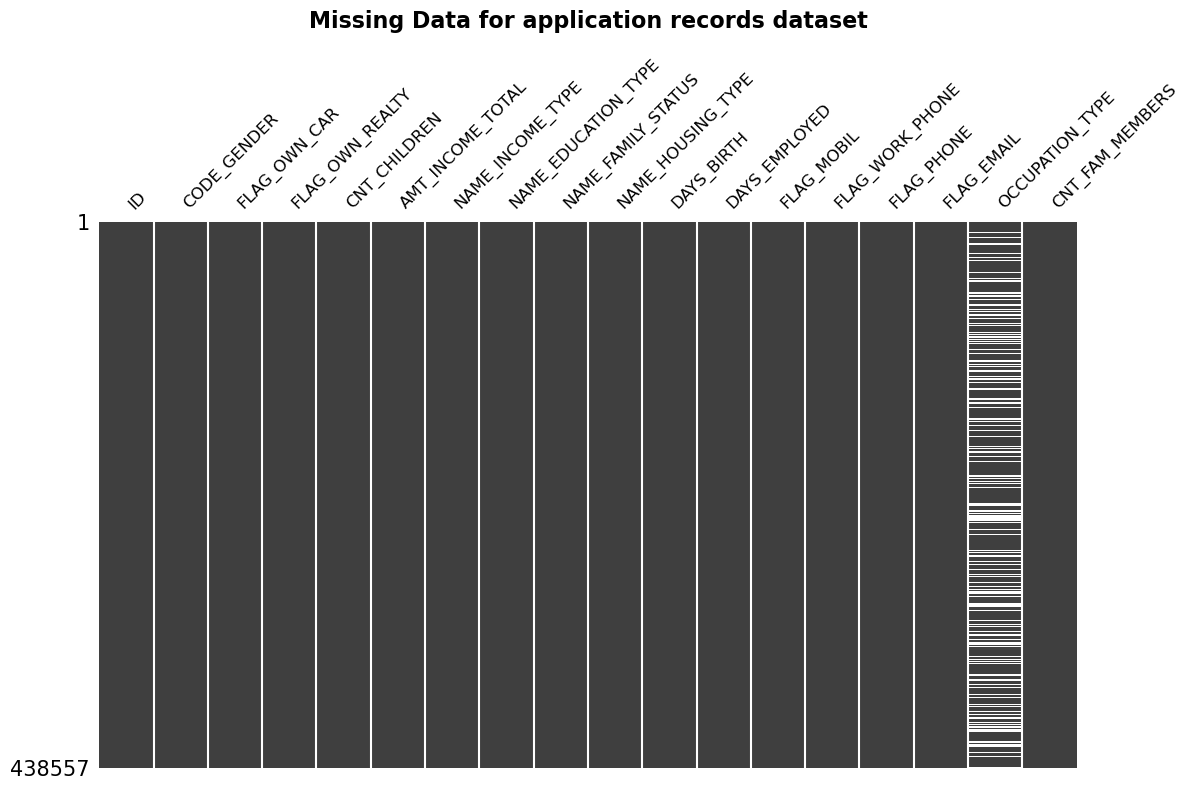

In [ ]:
# Plot missing rate
plot_missing_matrix(
    application_df,
    title="Missing Data for application records dataset",
    filename="application_missing_matrix.png",
)

Review:

According to the missing value analysis and in order to plot informative and useful pictures, I will: 
* remove  duplicates based on the `ID` column and keep the last entry if an ID is repeated, as it likely represents the most recent information.
* drop `OCCUPATION_TYPE` column because it contains excessive missing values (approximately 30.60% missing rate as identified in missing value analysis).


In [3]:
# 1. Remove duplicates based on ID column
application_df = application_df.drop_duplicates(subset='ID', keep='last')
application_df = application_df.reset_index(drop=True)

# 2. Drop OCCUPATION_TYPE column due to high missing rate
application_df = application_df.drop('OCCUPATION_TYPE', axis=1)

***

##### 2. Data Type Analysis

In [ ]:
# Unique value
print("Unique values of application_df:")
unique_value_summary(application_df)

Unique values of application_df:


,Column_Name,Num_Unique
12,FLAG_MOBIL,1
1,CODE_GENDER,2
3,FLAG_OWN_REALTY,2
2,FLAG_OWN_CAR,2
14,FLAG_PHONE,2
13,FLAG_WORK_PHONE,2
15,FLAG_EMAIL,2
7,NAME_EDUCATION_TYPE,5
8,NAME_FAMILY_STATUS,5
6,NAME_INCOME_TYPE,5


In [4]:
# categorize data
app_numerical_df, app_categorical_df = split_num_cat_features(application_df)

In [5]:
# Numerical data analysis
describe_numerical_features(app_numerical_df)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
CNT_CHILDREN,438510.0,0.427393,0.724887,0.0,0.0,0.0,1.00,19.0,1.806974,5.085223
AMT_INCOME_TOTAL,438510.0,187520.879910,110080.727479,26100.0,121500.0,161100.0,225000.00,6750000.0,8.835773,324.655274
DAYS_BIRTH,438510.0,-15997.815984,4185.058074,-25201.0,-19483.0,-15630.0,-12513.25,-7489.0,-0.160196,-1.048487
DAYS_EMPLOYED,438510.0,60562.020955,138766.410761,-17531.0,-3103.0,-1468.0,-371.00,365243.0,1.739536,1.027770
FLAG_MOBIL,438510.0,1.000000,0.000000,1.0,1.0,1.0,1.00,1.0,0.000000,0.000000
FLAG_WORK_PHONE,438510.0,0.206134,0.404529,0.0,0.0,0.0,0.00,1.0,1.452886,0.110878
FLAG_PHONE,438510.0,0.287763,0.452721,0.0,0.0,0.0,1.00,1.0,0.937611,-1.120891
FLAG_EMAIL,438510.0,0.108203,0.310637,0.0,0.0,0.0,0.00,1.0,2.522555,4.363302
CNT_FAM_MEMBERS,438510.0,2.194463,0.897210,1.0,2.0,2.0,3.00,20.0,0.919715,1.897702


In [6]:
# Categorical data analysis
describe_categorical_features(app_categorical_df)


Column: CODE_GENDER
Number of unique values: 2

Value counts:
CODE_GENDER
F    294412
M    144098
Name: count, dtype: int64

Column: FLAG_OWN_CAR
Number of unique values: 2

Value counts:
FLAG_OWN_CAR
N    275428
Y    163082
Name: count, dtype: int64

Column: FLAG_OWN_REALTY
Number of unique values: 2

Value counts:
FLAG_OWN_REALTY
Y    304043
N    134467
Name: count, dtype: int64

Column: NAME_INCOME_TYPE
Number of unique values: 5

Value counts:
NAME_INCOME_TYPE
Working                 226087
Commercial associate    100739
Pensioner                75483
State servant            36184
Student                     17
Name: count, dtype: int64

Column: NAME_EDUCATION_TYPE
Number of unique values: 5

Value counts:
NAME_EDUCATION_TYPE
Secondary / secondary special    301789
Higher education                 117509
Incomplete higher                 14849
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64

Column: NAME_FAMILY_STATUS
Numb

Review:

According to features' unique value and their data type, different visualization methods are applied: 
* Continuous numerical variables (`CNT_CHILDREN`, `AMT_INCOME_TOTAL`, `DAYS_BIRTH`, `DAYS_EMPLOYED`, `CNT_FAM_MEMBERS`) are analyzed using histograms to examine distribution shape, skewness, and potential outliers.
* `DAYS_BIRTH` and `DAYS_EMPLOYED` are transformed into more interpretable forms (age and employment duration) prior to visualization.
* Binary variables (`CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`) are visualized using pie charts to compare group proportions.
* Binary contact-related variables (`FLAG_WORK_PHONE`, `FLAG_PHONE`, `FLAG_EMAIL`) are visualized using bar charts due to class imbalance. Besides, as `FLAG_MOBIL` has only one unique value in the dataset and therefore does not provide any discriminatory information, it will be dropped during data cleaning.
* Multi-class categorical variables (`NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS`, `NAME_HOUSING_TYPE`) are analyzed using bar charts to compare category frequencies and identify dominant or rare classes.

***

##### 3. Distribution Analysis

In [7]:
histogram_col = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS']
pie_binary_col = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
bar_binary_col = ['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
bar_multi_col = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

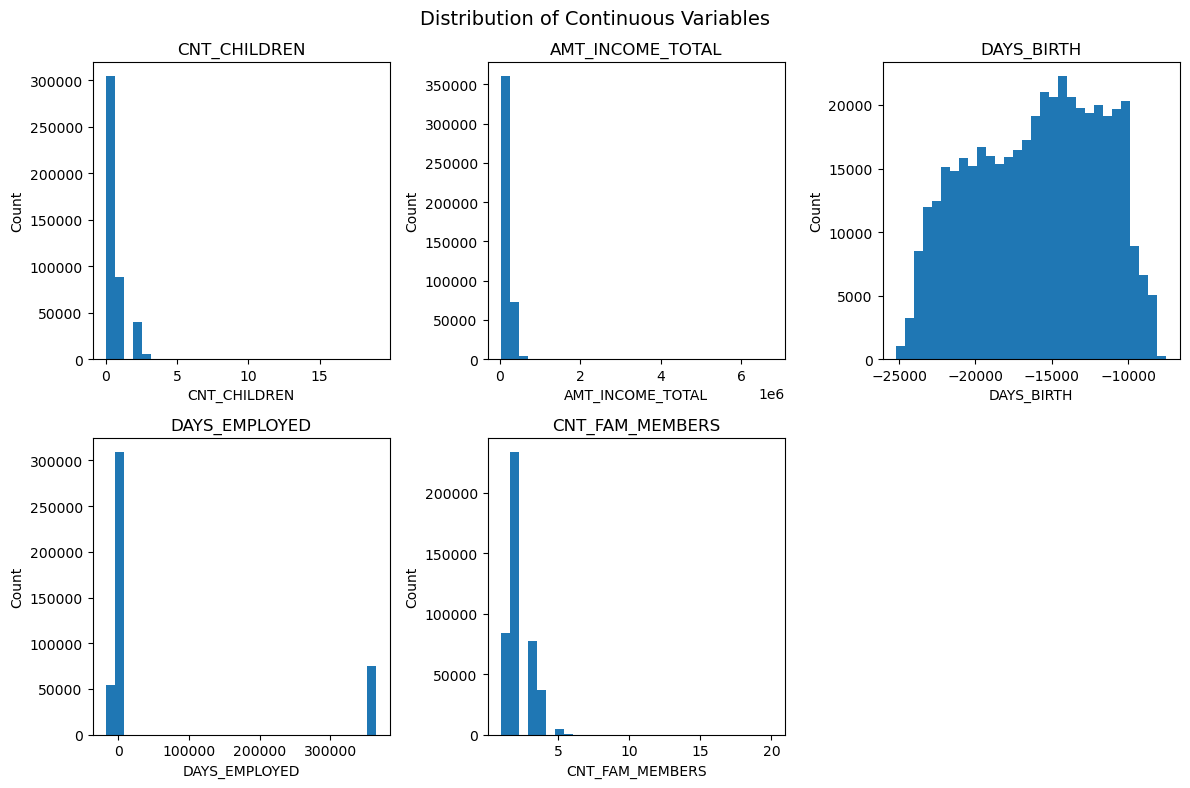

In [8]:
# histogram of continuous variables: CNT_CHILDREN, AMT_INCOME_TOTAL, DAYS_BIRTH, DAYS_EMPLOYED, CNT_FAM_MEMBERS
plot_histograms(
    df=application_df,
    columns=histogram_col,
    title="Distribution of Continuous Variables",
    save_name="distribution_histograms.png"
)

Review:

The continuous variables exhibit highly skewed distributions.
* `CNT_CHILDREN` and `CNT_FAM_MEMBERS` are heavily right-skewed, with most applicants having small household sizes.
* `AMT_INCOME_TOTAL` shows a long right tail, indicating the presence of extreme income values.
* `DAYS_BIRTH` follows a relatively smooth distribution after transformation, while `DAYS_EMPLOYED` contains extreme positive values, suggesting special codes for unemployment or data anomalies.

These observations indicate that outlier treatment and variable transformation are required before modeling.

In [ ]:
# pie chart of binary variables: CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY
plot_pie_charts(
    df=application_df,
    columns=pie_binary_col,
    title="Distribution of Binary Variables",
    save_name="distribution_binary_pie_charts.png"
)

Review:

The binary variables show clear class imbalance.
* Female applicants constitute a larger proportion of the dataset compared to males.
* Most applicants do not own a car, while a majority own real estate.

These variables are informative demographic indicators and can be directly incorporated into the predictive model.

In [ ]:
# bar chart of binary variables: FLAG_WORK_PHONE, FLAG_PHONE, FLAG_EMAIL
plot_binary_bar_charts(
    df=application_df,
    columns=bar_binary_col,
    title="Distribution of Contact Information Flags",
    save_name="distribution_binary_bar_charts.png"
)

Review:

The contact-related binary variables are strongly imbalanced.
* Most applicants do not provide work phone numbers or email addresses, while a larger share report having a personal phone.

The limited variation in these features suggests they may have weaker predictive power individually but could still provide complementary information when combined with other variables.

In [ ]:
# bar chart of multiclass variables: NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE
plot_multiclass_bar_charts(
    df=application_df,
    columns=bar_multi_col,
    title="Distribution of Multi-class Categorical Variables",
    save_name="distribution_multiclass_bar_charts.png"
)

Review:

The multi-class categorical variables display pronounced dominance of a few categories.
* Most applicants are working individuals with secondary or higher education, are married, and live in houses or apartments.
* Several categories have very low frequencies, indicating potential sparsity issues.

These features may require grouping or careful encoding to avoid noise in downstream modeling.

Pre-explanation:

1) For interpretability, `DAYS_BIRTH` is transformed into age in years (age_years = -`DAYS_BIRTH` / 365).
2) `DAYS_EMPLOYED` contains a special positive value indicating unemployment. To improve interpretability, I separate employment status and employment duration. When `DAYS_EMPLOYED` > 0, refer to "unemployed"; when `DAYS_EMPLOYED` < 0, transformed into employment duration in years(years_employed = -`DAYS_EMPLOYED` / 365).

In [ ]:
# solve DAYS_BIRTH and DAYS_EMPLOYED
application_df2 = transform_birth_and_employed(application_df)
application_df2.head()

,ID,DAYS_BIRTH,DAYS_EMPLOYED,age_years,is_unemployed,employed_years
0,5008804,-12005,-4542,32.867899,0,12.435318
1,5008805,-12005,-4542,32.867899,0,12.435318
2,5008806,-21474,-1134,58.792608,0,3.104723
3,5008808,-19110,-3051,52.320329,0,8.353183
4,5008809,-19110,-3051,52.320329,0,8.353183


In [ ]:
# plot DAYS_BIRTH and DAYS_EMPLOYED
plot_birth_and_employed(
    application_df2,
    title="Age & Employment Overview",
    save_name="distribution_birth_and_employed.png",
)

Review:

* The age distribution shows a broad and realistic range, with most applicants concentrated between working ages, indicating a mature applicant population.
* The unemployment indicator reveals a clear imbalance, with the majority of applicants being employed at the time of application.
* After clipping extreme values, employed_years remains right-skewed, suggesting that most applicants have relatively short employment histories, while a small group exhibits long job tenures.

***

##### 4. Outlier Analysis

Pre-explanation:

For better interpretability, `DAYS_BIRTH` and `DAYS_EMPLOYED` are transformed into age and employment-related features (`age_years`, `is_unemployed` and `employed_years`). The transformed features are merged back to the application data, and the original day-based variables are removed.

In [ ]:
application_df2 = application_df2.drop(
    columns=["DAYS_BIRTH", "DAYS_EMPLOYED"]
)

application_df = application_df.merge(
    application_df2,
    on="ID",
    how="left",
)

application_df = application_df.drop(
    columns=["DAYS_BIRTH", "DAYS_EMPLOYED"]
)

del application_df2

Pre-explanation:

Outliers analysis will be conducted only among numerical variables to see what detailed handling should do in the cleaning stage.

In [ ]:
numeric_cols = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "CNT_FAM_MEMBERS",
    "age_years",
    "employed_years",
]

In [ ]:
plot_numeric_boxplots(
    application_df,
    columns=numeric_cols,
    title="Boxplots of Numerical Variables",
    save_name="boxplots_numerical_variables"
)

Review:

The boxplots reveal substantial outliers across multiple numerical variables.
* `CNT_CHILDREN` and `CNT_FAM_MEMBERS` exhibit a small number of extreme values that are unlikely to represent typical household structures.
* `AMT_INCOME_TOTAL` shows a pronounced right tail with numerous high-income outliers, indicating strong skewness.
* `age_years` displays a relatively stable distribution with no extreme anomalies.
* `employed_years` contains many high-end outliers, reflecting long employment durations that may disproportionately influence model estimation.

Based on this analysis, selective clipping or transformation is considered for highly skewed variables in the data cleaning stage.

***

##### 5. Correlation Analysis

Pre-explanation:

Pairwise correlations will be conducted only among numerical variable to identify potential linear relationships.

In [ ]:
plot_correlation_heatmap(
    application_df,
    columns=numeric_cols,
    title="Correlation Heatmap of Numerical Variables",
    save_name="heatmap_numercial_variables"
)

Review:

* The correlation heatmap reveals a strong positive relationship between `CNT_CHILDREN` and `CNT_FAM_MEMBERS`, indicating overlapping information between household size variables.
* `age_years` shows a moderate negative correlation with household-related features and a moderate positive correlation with `employed_years`, reflecting realistic life-cycle patterns.
* `AMT_INCOME_TOTAL` exhibits very weak correlations with other numerical variables, suggesting that income provides largely independent information.

Overall, no severe multicollinearity is observed, suggesting that most numerical features can be jointly included in the model without causing instability, though closely related family size variables may require careful consideration during feature selection.


In [ ]:
del histogram_col, pie_binary_col, bar_binary_col, bar_multi_col

***

### III. Credit Performance EDA

##### 1. Missing Value Analysis

In [ ]:
# Missing value
print("Missing values of credit_df:")
missing_value_summary(credit_df)

Missing values of credit_df:


,missing_count,missing_rate
ID,0,0.0
MONTHS_BALANCE,0,0.0
STATUS,0,0.0


In [ ]:
# Plot missing
plot_missing_matrix(
    credit_df,
    title="Missing Data for credit records dataset",
    filename="credit_missing_matrix.png",
)

Review:

No missing values are observed in the credit records dataset. This ensures that all monthly credit history information can be directly used for aggregation and target construction without imputation.


***

##### 2. Panal Data Analysis

In [ ]:
# Unique value
print("Unique values of credit_df:")
unique_value_summary(credit_df)

In [ ]:
# analysis credit performance per applicant
records_per_id = plot_credit_records_per_id(
    credit_df,
    title="Distribution of Credit History Length per Applicant",
    save_name="distribution_creditrecords_ID"
)

Review:

The distribution shows substantial heterogeneity in the number of monthly credit records across applicants.
While most applicants have relatively short credit histories, a non-negligible group is observed over long time horizons of up to 60 months.

In [ ]:
# analysis time structure of credit record
plot_months_balance_distribution(
    credit_df,
    title="Distribution of Credit Records Over Time",
    save_name="distribution_creditrecords_month"
)

Review:

The distribution of `MONTHS_BALANCE` indicates that most credit records are concentrated in recent months, with the number of observations gradually decreasing as the time horizon extends backward. This pattern suggests that applicants typically have more complete information in recent periods, reinforcing the need to aggregate credit behavior over time at the applicant level.

***

##### 3. Credit 'STATUS' Analysis

In [ ]:
status_counts = plot_status_distribution(
    credit_df,
    title="Credit STATUS Distribution (Counts)",
    normalize=False,
    save_name="credit_status_counts.png",
)

In [ ]:
status_ratio = plot_status_distribution(
    credit_df,
    title="Credit STATUS Distribution (Proportions)",
    normalize=True,
    save_name="credit_status_ratio.png",
)

Review:

The distribution of STATUS values is highly imbalanced. Most monthly records correspond to non-delinquent states, namely “C” (paid off), “X” (no loan), and “0” (minor delay), while severe delinquency statuses occur very infrequently. This indicates that default-like events are rare at the monthly level, highlighting strong class imbalance in raw credit records.

In [ ]:
STATUS_SEVERITY = {
    "X": 0,
    "C": 0,
    "0": 1,
    "1": 2,
    "2": 3,
    "3": 4,
    "4": 5,
    "5": 6,
}

In [ ]:
credit_df_sev = add_status_severity(
    credit_df,
    status_severity=STATUS_SEVERITY,
    status_col="STATUS",
    new_col="severity",
)

In [ ]:
sev_counts = plot_severity_distribution(
    credit_df_sev,
    title="Severity Distribution (Counts)",
    normalize=False,
    save_name="credit_severity_counts.png",
)

In [ ]:
sev_ratio = plot_severity_distribution(
    credit_df_sev,
    title="Severity Distribution (Proportions)",
    normalize=True,
    save_name="credit_severity_ratio.png",
)

Review:

After mapping `STATUS` values to ordinal severity levels, the distribution remains heavily skewed toward low-risk categories. The majority of observations fall into severity 0 and 1, while higher severity levels are extremely rare. 

***

##### 4. ID-level Aggregation

Pre-explanation:

Credit behavior is aggregated to the applicant level.

In [ ]:
credit_agg = aggregate_credit_by_id(credit_df_sev)
credit_agg.head()

In [ ]:
plot_credit_history_length(
    credit_agg,
    title="Distribution of Credit History Length",
)

In [ ]:
plot_max_severity_distribution(
    credit_agg,
    title="Maximum Credit Severity per Applicant",
)

In [ ]:
plot_ever_severe_pie(
    credit_agg,
    title="Applicants with Severe Delinquency History",
)

Review:

* The first graph illustrates that substantial variation in credit history length across applicants. While most applicants are observed for a limited number of months, a meaningful subset has long credit histories extending up to 60 months. This heterogeneity confirms the need to consider both the duration and content of credit history in risk assessment.
* The second graph indicates that the maximum severity distribution indicates that most applicants experience only low levels of delinquency over their observed credit history. However, a non-negligible group reaches higher severity levels, reflecting the presence of significant credit risk concentrated among a small subset of applicants.
* The third graph shows that only a small proportion of applicants have experienced at least one severe delinquency event. This extreme imbalance highlights the rarity of severe credit deterioration and motivates a binary target definition based on the presence of severe delinquency over time.

Overall, these ID-level aggregations demonstrate that credit risk is concentrated among a small fraction of applicants and must be inferred from longitudinal patterns rather than single observations.

***

##### 5. Target Variable Construction

Pre-explanation:

Early delinquency (1–29 or 30–59 days past due) may reflect temporary liquidity issues and does not necessarily indicate long-term credit risk. Therefore, I focus on more severe delinquency to define bad credit outcomes.
Hence, I definite:
1) **Bad customer**: An applicant who has experienced at least one month with severity ≥ 3 (i.e. 60+ days past due).
2) **Good customer**: An applicant who has never experienced severity ≥ 3 during the observation period.

In [ ]:
credit_target_df = build_credit_target(
    credit_df=credit_df,
    status_severity=STATUS_SEVERITY,
    bad_severity_threshold=3,
)

In [ ]:
credit_target_df.head()

In [ ]:
credit_target_df["target"].value_counts(normalize=True)

In [ ]:
credit_target_df.groupby("target")["max_severity"].describe()

In [ ]:
credit_target_df["total_months_per_ID"].describe()

***

## Clean and Process Data

In [ ]:
from CreditCardApproval.cleaning import (
    rename_application_columns,
    handle_application_missing,
    clip_outliers_application,
    recode_categorical_variables,
    merge_application_with_target,
    select_final_variables
)

### 1. Rename variables

To improve readability and consistency for modelling, while preserving the original semantic meaning of variables, I rename all the original variables into snake_case.

In [ ]:
APPLICATION_RENAME_MAP = {
    "AMT_INCOME_TOTAL": "annual_income",
    "CNT_CHILDREN": "children_number",
    "CNT_FAM_MEMBERS": "family_size",

    "CODE_GENDER": "gender",
    "FLAG_OWN_CAR": "own_car",
    "FLAG_OWN_REALTY": "own_realty",
    "FLAG_WORK_PHONE": "own_work_phone",
    "FLAG_PHONE": "own_phone",
    "FLAG_EMAIL": "own_email",

    "NAME_INCOME_TYPE": "income_type",
    "NAME_EDUCATION_TYPE": "education_type",
    "NAME_FAMILY_STATUS": "family_status",
    "NAME_HOUSING_TYPE": "housing_type",
}

In [ ]:
# rename variables
application_df_clean = rename_application_columns(application_df)
application_df_clean.info()

### 2. Solve missing values 

Missing values in the application dataset are structural rather than random, mainly arising from unemployed applicants. Therefore, missing values are handled using rule-based imputation rather than statistical filling.

In [ ]:
# solving missing value of "employed_years"
application_df_clean = handle_application_missing(application_df_clean)
application_df_clean.isna().sum()

### 3. Solve outliers



Based on the boxplot analysis, several numerical variables exhibit strong right-skewness and extreme values. Instead of removing observations, quantile-based clipping is applied to limit the influence of outliers while preserving the full sample size for modeling. After clipping, extreme values are effectively controlled while the overall distribution remains intact.

In [ ]:
# solving outliers of numerical variables
application_df_clean = clip_outliers_application(application_df_clean)
plot_numeric_boxplots(
    application_df_clean,
    columns=["annual_income", "employed_years", "children_number", "family_size"],
    title="Boxplots of Numerical Variables (Cleaned)",
    save_name="boxplots_numerical_variables (Cleaned)"
)

### 4. Recode variables


Based on variable definitions and EDA results, it can be found that several categorical variables contain sparse or semantically overlapping categories, which can be recoded into broader, meaningful groups to reduce sparsity and improve model stability.

In [ ]:
# recode categorical variables
application_df_clean = recode_categorical_variables(application_df_clean)
unique_value_summary(application_df_clean[["income_type_recoded", "education_level", "family_status_recoded", "housing_status"]])


### 5. Prepare final dataset

The target variable is constructed from post-issuance credit behavior and merged with cleaned application features at the applicant level. Only applicants with available credit history are retained. The final dataset is free of missing values and suitable for downstream predictive modeling.

In [ ]:
# merge credit_target_df with cleaned application data
final_df = merge_application_with_target(
    application_df_clean,
    credit_target_df,
)

final_df.shape

In [ ]:
# drop useless vairables and rename
final_df = select_final_variables(final_df)

In [ ]:
# overview of final data
final_df["target"].value_counts(normalize=True)
final_df.isna().sum().sort_values(ascending=False).head(10)
final_df["ID"].is_unique
final_df.head()

In [ ]:
final_df.to_parquet(
    "data/prepared_dataset.parquet",
    index=False,
)